In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import datetime as dt


In [58]:
stocks = ["PLTR","BABA","DIS","WIX"]
weights = np.array([0.10,0.10,0.10,0.70])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=252*3)

In [59]:
prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

Media diaria retornos:
Ticker
BABA    0.001874
DIS     0.000405
PLTR    0.004928
WIX    -0.000793
dtype: float64
\nMatriz de covarianza:
Ticker      BABA       DIS      PLTR       WIX
Ticker                                        
BABA    0.000764  0.000051  0.000193  0.000150
DIS     0.000051  0.000325  0.000241  0.000139
PLTR    0.000193  0.000241  0.001737  0.000289
WIX     0.000150  0.000139  0.000289  0.000951


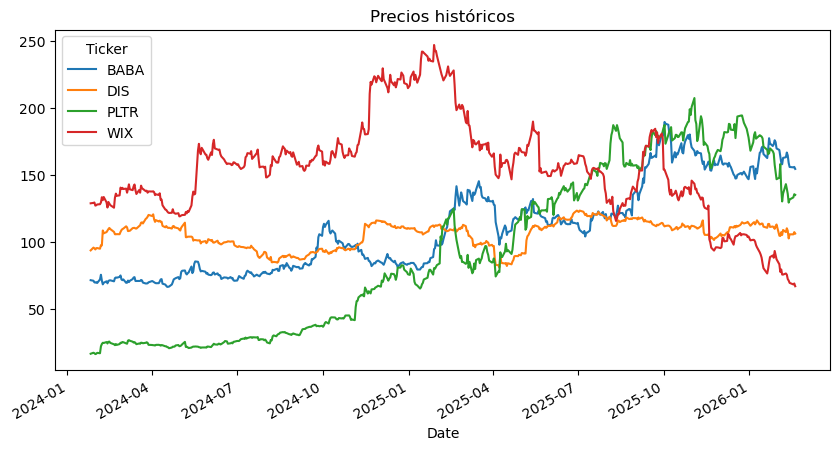

In [60]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

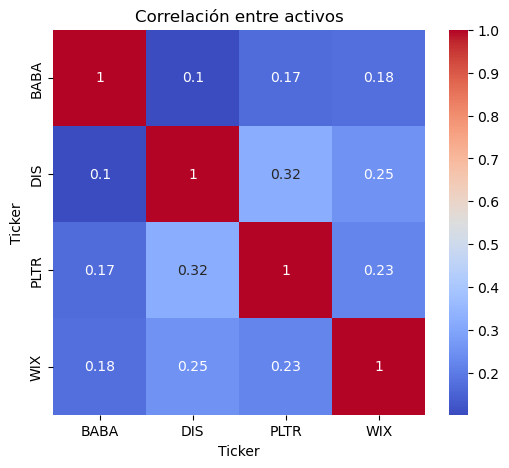

In [61]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

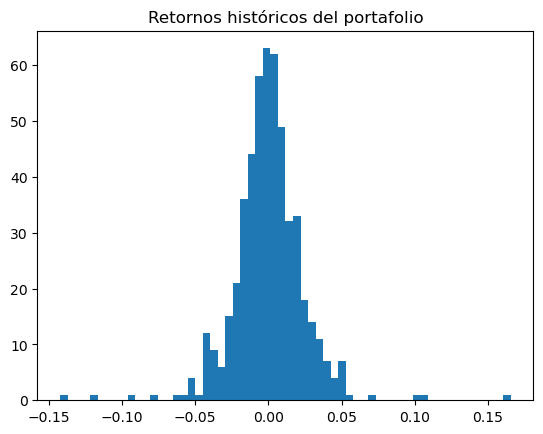

Volatilidad histórica diaria: 0.02418431968004852


In [62]:
portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())

In [63]:
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

In [64]:
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

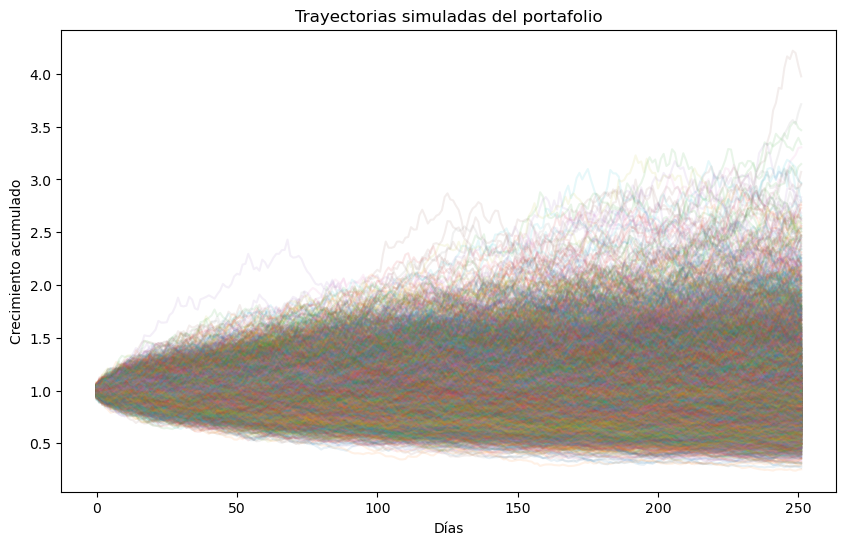

In [65]:
plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

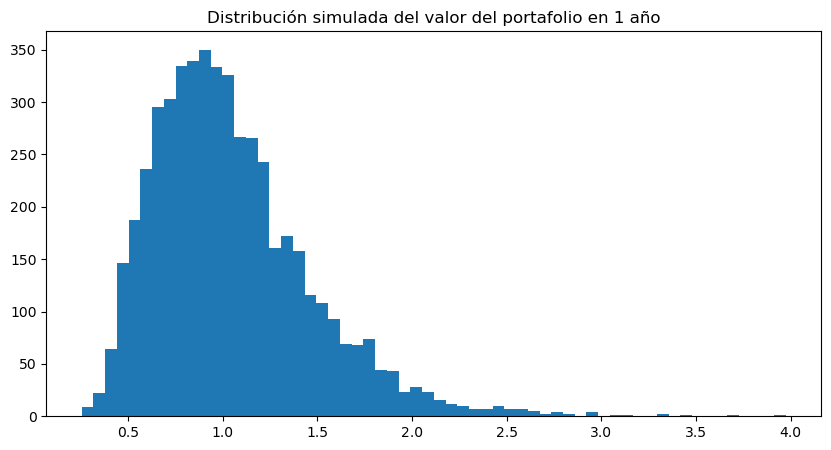

Valor esperado final: 1.0474002145397245
Probabilidad de pérdida: 0.5244


In [66]:
final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))

In [67]:
#Valor promedio final del portafolio
print("Valor promedio final del portafolio:", final_values.mean())
# Valor máximo observado
print("Valor máximo observado:", final_values.max())
# Valor mínimo observado
print("Valor mínimo observado:", final_values.min())

Valor promedio final del portafolio: 1.0474002145397245
Valor máximo observado: 3.9762749372929056
Valor mínimo observado: 0.2546379674983331


**Respondido antes de cambiar el código:**

¿Las trayectorias simuladas son similares entre sí o muy distintas? Son similares ya que sus componentes también lo son.

¿La dispersión aumenta con el tiempo? Si.

¿Qué observas en la distribución final del portafolio? Está sesgada hacia los valores más positivos.

**Después de cambiar los tickers y el peso:**

¿Qué observas al modificar el portafolio o el horizonte? También está sesgado y las simulaciones parecen muy similares. Aunque la correlación es muy diferente. Eso sí, entre más tiempo, más dispersión. Como le puse mucho peso a WIX que ha tenido un comportamiento bajista, ahora los rendimientos se fueron más hacia la izquierda (negativas). 


# Clase 10:  Value at Risk con Monte Carlo y Volatilidad Dinámica (EWMA)

In [68]:

# Descarga de datos
tickers = ["AAPL","MSFT","GOOGL","AMZN"]
weights = np.array([0.25,0.25,0.25,0.25])

end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)

data = yf.download(tickers,start=start,end=end)["Close"]
returns = data.pct_change().dropna()

n_sim = 10000
n_days = 252
n_assets = len(tickers)

[*********************100%***********************]  4 of 4 completed


In [69]:
lambda_ = 0.94

ewma_var = returns.var().copy()
ewma_vol_series = []

for t in range(len(returns)):
    r_t = returns.iloc[t]
    ewma_var = lambda_ * ewma_var + (1 - lambda_) * (r_t ** 2)
    ewma_vol_series.append(np.sqrt(ewma_var))

ewma_vol_df = pd.DataFrame(ewma_vol_series, 
                           index=returns.index, 
                           columns=returns.columns)

In [70]:
corr_matrix = returns.corr()
L_corr = np.linalg.cholesky(corr_matrix)

In [71]:
sigma_t = ewma_vol_df.iloc[-1].values
portfolio_paths = np.zeros((n_sim,n_days))


for s in range(n_sim):

    sigma = sigma_t.copy()
    prices_sim = np.ones(n_assets)

    for t in range(n_days):

        z = np.random.normal(size=n_assets)
        correlated = L_corr @ z

        r = sigma * correlated

        prices_sim = prices_sim * (1 + r)

        port_ret = np.dot(weights, r)

        if t == 0:
            portfolio_paths[s, t] = 1 + port_ret
        else:
            portfolio_paths[s, t] = portfolio_paths[s, t-1] * (1 + port_ret)

        sigma = np.sqrt(lambda_ * sigma**2 + (1 - lambda_) * (r**2))

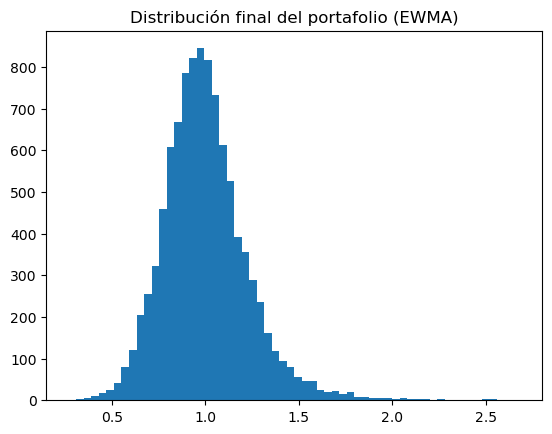

VaR 95%: 0.32799311225979944
Expected Shortfall 95%: 0.40465452492896925


In [72]:
final_values = portfolio_paths[:,-1]

plt.hist(final_values,bins=60)
plt.title("Distribución final del portafolio (EWMA)")
plt.show()

var_95 = np.percentile(final_values,5)
es_95 = final_values[final_values<=var_95].mean()

print("VaR 95%:",1-var_95)
print("Expected Shortfall 95%:",1-es_95)

Calcular VaR (%) para tu portafolio a 15 días al 95% de confianza
- Con MGB con volatilidad constante
    - Usando 1 año de data histórica
    - Usando 3 años de data histórica
    - Usando 5 años de data histórica
    - Usando 10 años de data histórica
- Con EWMA
    - Usando 1 año de data histórica. Lambda =.94
    - Usando 3 años de data histórica. Lambda =.94
    - Usando 5 años de data histórica. Lambda =.94
    - Usando 10 años de data histórica. Lambda =.94
- Con EWMA
    - Usando 1 año de data histórica. Lambda =.8
    - Usando 3 años de data histórica. Lambda =.8
    - Usando 5 años de data histórica. Lambda =.8
    - Usando 10 años de data histórica. Lambda =.8

Construir una tabla comparativa en Python


In [ ]:
## Lo haremos con fucniones por practicidad

z = norm.ppf(1 - confidence)   
horizon = 15                   

def get_portfolio_returns(years):

    end = dt.datetime.today()
    start = end - dt.timedelta(days=252*years)

    prices = yf.download(tickers, start=start, end=end, progress=False)["Close"]

    returns = prices.pct_change().dropna()

    portfolio_returns = returns @ weights

    return portfolio_returns

In [ ]:

## Funciones de var
# MGB
def constant_volatility(portfolio_returns):

    return portfolio_returns.std()


# EWMA
def ewma_volatility(portfolio_returns, lambda_):

    var = portfolio_returns.var()

    for r in portfolio_returns:
        var = lambda_ * var + (1 - lambda_) * r**2

    return np.sqrt(var)


# VaR 
def calculate_var_percent(volatility):

    var = - z * volatility * np.sqrt(horizon)

    return var * 100


In [81]:
# Calculos para la lista de años.
years_list = [1, 3, 5, 10]
results = []

for years in years_list:

    portfolio_returns = get_portfolio_returns(years)

    vol_const = constant_volatility(portfolio_returns)
    var_const = calculate_var_percent(vol_const)

    results.append({
        "Metodo": "MGB Volatilidad Constante",
        "Lambda": "-",
        "Años": years,
        "VaR (%)": var_const
    })

    # EWMA lambda 0.94 
    vol_ewma_94 = ewma_volatility(portfolio_returns, 0.94)
    var_ewma_94 = calculate_var_percent(vol_ewma_94)

    results.append({
        "Metodo": "EWMA",
        "Lambda": 0.94,
        "Años": years,
        "VaR (%)": var_ewma_94
    })

    # EWMA lambda 0.8 
    vol_ewma_80 = ewma_volatility(portfolio_returns, 0.9)
    var_ewma_80 = calculate_var_percent(vol_ewma_80)

    results.append({
        "Metodo": "EWMA",
        "Lambda": 0.8,
        "Años": years,
        "VaR (%)": var_ewma_80
    })


In [ ]:
# Tabla
var_table = pd.DataFrame(results)

var_table = var_table.pivot_table(
    index=["Metodo", "Lambda"],
    columns="Años",
    values="VaR (%)"
)

var_table = var_table.round(9)
print(var_table)

Años                                    1         3         5          10
Metodo                    Lambda                                         
EWMA                      0.8     7.537995  7.537995  7.537995   7.537995
                          0.94    7.432605  7.432692  7.432692   7.432692
MGB Volatilidad Constante -       6.751906  8.917210  9.642473  10.731550
